In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import gc
import numpy as np
import matplotlib.pyplot as plt

from lmfit import Model as LM_Model
from lmfit import Parameters as LM_Parameters

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from ndspec.Response import ResponseMatrix
from ndspec.Timing import PowerSpectrum, CrossSpectrum
import ndspec.Models as models

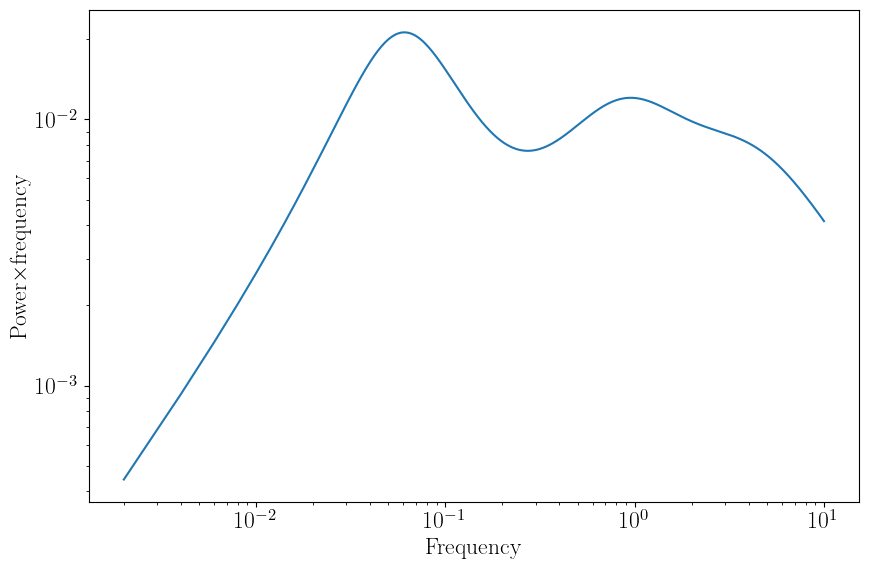

15469

In [2]:
#Define our time grid and power spectrum object
obs_time = 5e2
dt = 0.05
N = int(obs_time/dt)

times = np.linspace(dt,obs_time,N)

psd_model = PowerSpectrum(times)

def lorentz(freq,peak_f,q,rms):
    par_array = np.array([peak_f,q,rms])
    model = models.lorentz(freq,par_array)
    return model

#Define our model for the power spectrum directly in Fourier space, as a sum of
#two Lorentzians
Lorentz_model = LM_Model(lorentz, prefix="l1_") + \
                LM_Model(lorentz, prefix="l2_") + \
                LM_Model(lorentz, prefix="l3_")

Lorentz_model_parameters = LM_Parameters()
Lorentz_model_parameters.add_many(('l1_peak_f', 0.06, True, 1e-3, 0.3),
                                  ('l1_q', 0.5, True, 0, 2),
                                  ('l1_rms', 0.20, True),
                                  ('l2_peak_f', 0.9, True, 0.3, 1.25),
                                  ('l2_q', 0.3, True, 0, 2),
                                  ('l2_rms', 0.15, True),
                                  ('l3_peak_f', 4.0, True, 1.25, 10),
                                  ('l3_q', 0.2, True, 0, 2),
                                  ('l3_rms', 0.12, True),
                                 )

#Assign the model array to power_spec and plot the result
psd_model.set_psd_model(Lorentz_model,Lorentz_model_parameters)
psd_model.compute_psd()    
psd_model.plot_psd()
gc.collect()

<Axes: xlabel='Time (s)', ylabel='counts'>

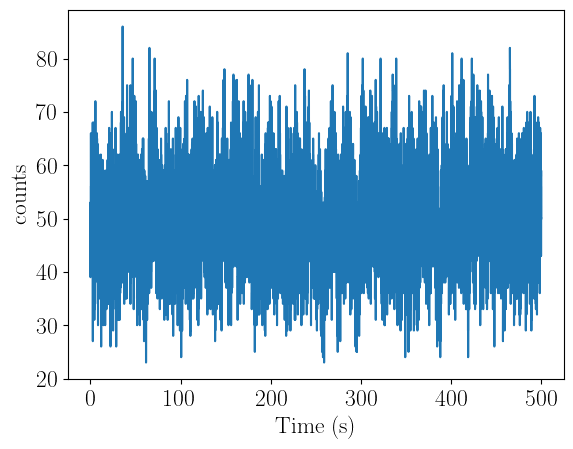

In [3]:
from ndspec.Simulator import simulate_lightcurve

countrate = 1000

simulated_observation = simulate_lightcurve(psd_model,obs_time,dt,countrate)

simulated_observation.plot()

In [4]:
print(np.mean(simulated_observation.counts)/dt)

998.2819999999999


In [5]:
nustar = os.getcwd() + "/data/"

rmfpath = nustar + "/nu90401309004A01_sr.rmf"
fpma = ResponseMatrix(rmfpath)
arfpath = nustar + "/nu90401309004A01_sr.arf"
fpma.load_arf(arfpath)

Arf missing, please load it
Arf loaded


In [6]:
import ndspec.XspecInterface as xsmodels

def tbabs(ear, params):
    pass

def powerlaw(ear, params):
    pass

def diskbb(ear, params):
    pass

xspec_library = xsmodels.FortranInterface()

xspec_library.load_models({
    "tbabs": tbabs,
    "powerlaw": powerlaw,
    "diskbb": diskbb,
})

def ndspec_tbabs(ear,nH):
    par_array = np.array([nH])
    model = xspec_library.tbabs(ear,par_array)
    return model

def ndspec_powerlaw(ear,gamma,norm_pl):
    par_array = np.array([gamma,norm_pl])
    model = xspec_library.powerlaw(ear,par_array)
    return model

def ndspec_diskbb(ear,Tin,norm_dbb):
    norm_dbb = 10**norm_dbb
    par_array = np.array([Tin,norm_dbb])
    model = xspec_library.diskbb(ear,par_array)
    return model

sim_model = LM_Model(ndspec_tbabs)*(LM_Model(ndspec_diskbb)+LM_Model(ndspec_powerlaw))

#make sure that these normalizations make sense for xspec models as well
sim_params = sim_model.make_params(nH=dict(value=0.1,min=0.05,max=100,vary=True),
                                   Tin=dict(value=0.25,min=0.15,max=5.,vary=True),
                                   norm_dbb=dict(value=5.7,min=-2.,max=8.,vary=True),
                                   gamma=dict(value=1.6,min=1.3,max=3.5,vary=True), 
                                   norm_pl=dict(value=6,min=1e-1,max=1e6,vary=True)
                                   )


xspec_library.print_model_info()


 Solar Abundance Vector set to angr:  Anders E. & Grevesse N. Geochimica et Cosmochimica Acta 53, 197 (1989)
 Cross Section Table set to vern:  Verner, Ferland, Korista, and Yakovlev 1996
Initialized Xspec models:
tbabs:
  type: mul
  function called: C_tbabs
  parameters:
    nH: value: 1.0, min: 0.0, max: 1000000.0, unit: 10^22

powerlaw:
  type: add
  function called: C_powerLaw
  parameters:
    PhoIndex: value: 1.0, min: -3.0, max: 10.0, unit: n/a
    norm: value: 1, min: 0, max: 1e+20, unit: n/a

diskbb:
  type: add
  function called: xsdskb
  parameters:
    Tin: value: 1.0, min: 0.0, max: 1000.0, unit: keV
    norm: value: 1, min: 0, max: 1e+20, unit: n/a



In [7]:
from ndspec.Simulator import simulate_time_averaged

simulated_spectrum = simulate_time_averaged(fpma,sim_model,sim_params,exposure_time=5e4)

/home/matteo/Software/nDspec/src/ndspec/Response.py:653: RuntimeWarning: invalid value encountered in divide
  unfold_model = array/unfold_array


20

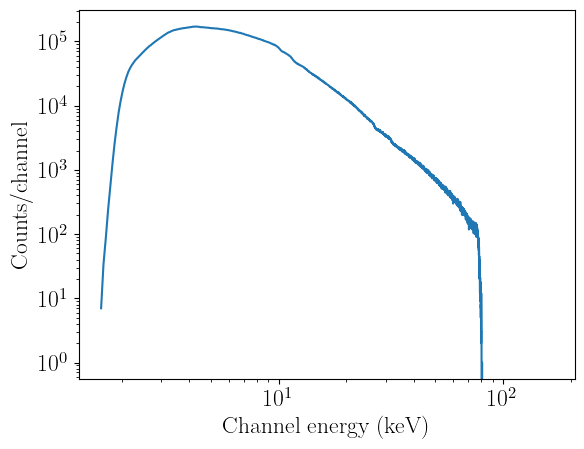

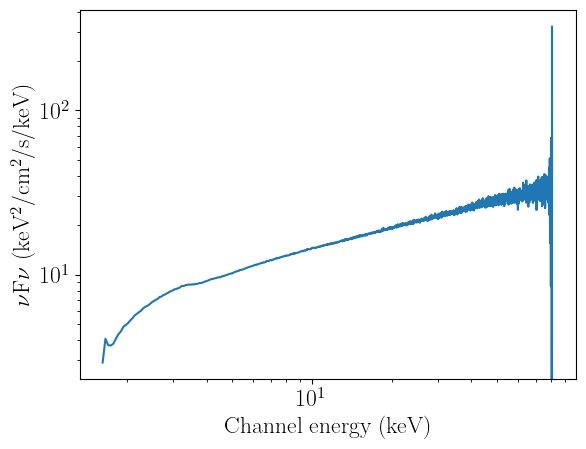

In [8]:
midpoint = 0.5*(fpma.emax+fpma.emin)

plt.figure(1)
plt.loglog(midpoint,simulated_spectrum)
plt.xlabel("Channel energy (keV)")
plt.ylabel("Counts/channel")

plt.figure(2)
plt.loglog(midpoint,fpma.unfold_response(simulated_spectrum,units_in="channel")*midpoint**2/5e4)
plt.xlabel("Channel energy (keV)")
plt.ylabel("$\\rm{\\nu}$F$\\rm{\\nu}$ (keV$^2$/cm$^2$/s/keV)")
gc.collect()

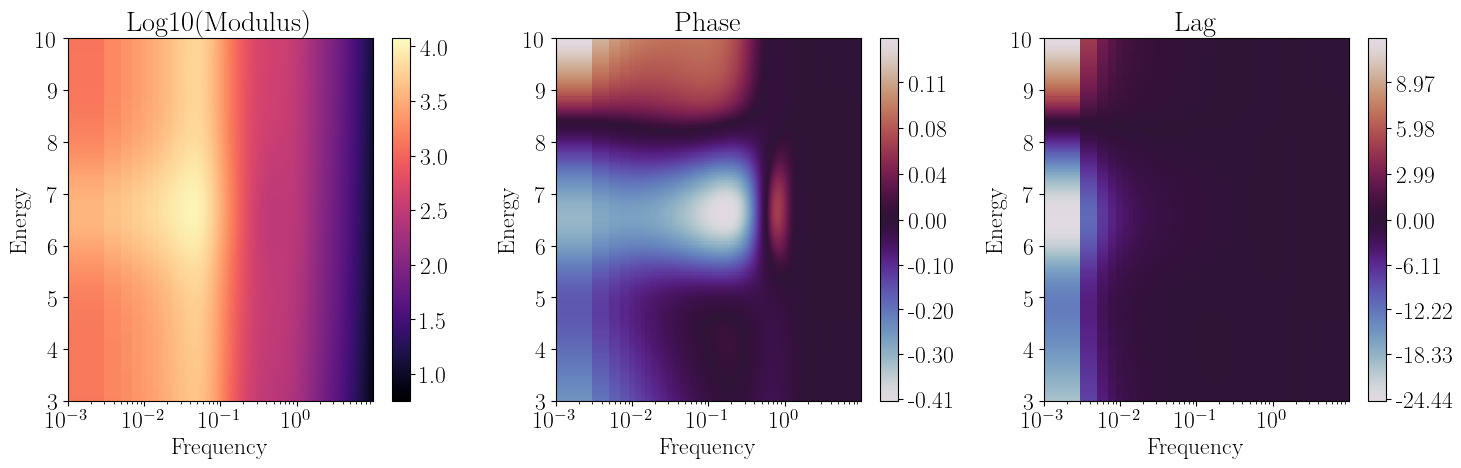

67338

In [9]:
#turn the stuff above into a function
#first set up the response we want
rebin_grid = np.geomspace(3,78,21)
rebin_grid = np.append(rebin_grid,fpma.emin[0])
rebin_grid = np.append(rebin_grid,fpma.emax[-1])
rebin_grid = np.unique(np.sort(rebin_grid))
rebin_fpma = fpma.rebin_channels(rebin_grid[:-1],rebin_grid[1:])

#from this response, we take the energy grid and calculate the models 
energ_grid = 0.5*(rebin_fpma.energ_lo+rebin_fpma.energ_hi)
ref_emin = 3
ref_emax = 78

#now we prepare the grid of energy bounds to calculate our spectral model, and calculate it
rebin_ear = np.append(rebin_fpma.energ_lo,rebin_fpma.energ_hi[-1])
spectrum_model = sim_model.eval(sim_params,ear=rebin_ear)

#next we set up the background - optimi
bkg_rate = np.zeros(rebin_fpma.n_chans-1)

#first the pivoting powerlaw
pl_norm = 5.
pl_slope = -1.6
gamma_0 = 0.3
gamma_nu = -0.1
phi_0 = -0.3
phi_nu = -0.1
nu_0 = psd_model.freqs[0]
piv_transfer = models.pivoting_pl(psd_model.freqs,energ_grid,np.array([pl_norm,pl_slope,gamma_0,gamma_nu,phi_0,phi_nu,nu_0]))

continuum = CrossSpectrum(psd_model.times,energ=energ_grid)
continuum.set_transfer(piv_transfer)
continuum.set_psd_weights(psd_model.power_spec)
continuum.set_reference_energ([ref_emin,ref_emax])
continuum.cross_from_transfer()

#now the reverberation
gauss_norm = 2.5
gauss_sigma = 1.5
gauss_center = 6.5
rise_slope = 3
decay_slope = -2 
peak_time = 15
width_slope = -0.2

gauss_flash = models.gauss_bkn(psd_model.times,energ_grid,
                               np.array([gauss_norm,gauss_sigma,gauss_center,rise_slope,
                                         decay_slope,peak_time,width_slope]),
                               )

reverb = CrossSpectrum(psd_model.times,energ=energ_grid)
reverb.set_psd_weights(psd_model.power_spec)
reverb.set_impulse(gauss_flash)
reverb.set_reference_energ([ref_emin,ref_emax])
reverb.cross_from_irf()

#finally we combine both
full_model = CrossSpectrum(psd_model.times,energ=energ_grid)
full_model.set_psd_weights(psd_model.power_spec)
full_model.set_transfer(continuum.trans_func + reverb.trans_func)
full_model.set_reference_energ([ref_emin,ref_emax])
full_model.cross_from_transfer()
full_model.plot_cross_2d(energy_limits=[3,10])
gc.collect()
#we are now ready to simulate our observation

In [10]:
def simulate_prototype(response,time_avg_model,cross_model,bkg_rate,freq_bounds,ref_bounds,coh,pow,exposure):
    #convolve our time-averaged and cross spectra with the response
    spectrum_model = response.convolve_response(time_avg_model)
    convolved_model = response.convolve_response(cross_model)    
    #get the lags, real and imaginary parts of our convolved cross spectrum
    lag_model = convolved_model.lag_energy(freq_bounds)    
    real_model = convolved_model.real_energy(freq_bounds)
    imag_model = convolved_model.imag_energy(freq_bounds)
    
    #now we calculate the power and noise in the reference band, given the models we have
    ref_ilo = np.argmin(np.abs(response.emin-ref_bounds[0]))
    ref_ihi = np.argmin(np.abs(response.emax-ref_bounds[1]))
    # Calculate background in reference band - the +1 is necessary because the bounds are open rather than closed, ie [,) rather than [,]
    br = np.sum(bkg_rate[ref_ilo:ref_ihi+1])
    # Calculate reference band power (absolute rms^2)
    ref_pow = pow*(freq_bounds[1]+freq_bounds[0])*0.5
    Pr = ref_pow * np.sum(real_model[ref_ilo:ref_ihi+1])
    # Calculate reference band Poisson noise (absolute rms^2)
    mur = np.sum(spectrum_model[ref_ilo:ref_ihi+1])
    # Calculate total noise
    Prnoise = 2.0 * (br + mur)

    #next we set up the channels of interest
    sub_Elo = response.emin
    sub_Ehi = response.emax    
    #we already have rebinned the matrix in the channels appropriately, so we only need one set of
    #indexes rather than two like for the reference which can cover multiple channels
    sub_i = np.array([np.argmin(np.abs(response.emin - e)) for e in sub_Elo],dtype=int)
    
    #now finally run the simulation, given the input coherence and exposure   
    lagsim = []
    dlag = []

    for index in sub_i:
        #calculate the total noise in each subject band
        mus = np.sum(spectrum_model[index:index+1])
        bs = np.sum(bkg_rate[index:index+1])
        Psnoise = 2*(mus+bs)
        #calculate the cross spectrum contributions for the error
        realcross = np.sum(real_model[index:index+1])
        imagcross = np.sum(imag_model[index:index+1])
        crosssquared = pow**2*(realcross**2+imagcross**2)
        #calculate the error
        lag_err = 1+Prnoise/Pr
        lag_err *= (crosssquared*(1-coh) - Psnoise*Pr)
        lag_err /= (crosssquared*coh)
        lag_err /= (2*exposure * (freq_bounds[1]-freq_bounds[0]))
        lag_err = np.abs(lag_err)**0.5
        lag_err /= (2.0*np.pi*np.diff(freq_bounds))
        #generate lags with Gaussian noise rescaled by the error
        lag_val = lag_model[index] + np.random.normal(loc=0,scale=1,size=1) * lag_err
        dlag = np.append(dlag,lag_err)
        lagsim = np.append(lagsim,lag_val)
    
    return lagsim,dlag, response.emin, response.emax

In [11]:
from ndspec.Simulator import simulate_lag_energy

fmin = 5e-3
fmax = 5e-2
coherence = 1
power = 5e-3
exposure = 5e4

lag_sim, lag_err, emin , emax = simulate_lag_energy(rebin_fpma,spectrum_model,full_model,
                                                    bkg_rate,[fmin,fmax],[ref_emin,ref_emax],
                                                    coherence,power,exposure)

ImportError: cannot import name 'simulate_lag_energy' from 'ndspec.Simulator' (/home/matteo/Software/nDspec/src/ndspec/Simulator.py)

In [ ]:
ebounds = 0.5*(emin+emax)

plt.figure(1)
plt.step(ebounds,lag_sim,where='mid',color="C0")
plt.errorbar(ebounds,lag_sim,yerr=lag_err,ls="",color="C0")
plt.plot(full_model.energ,full_model.lag_energy([fmin,fmax]),color="C1")
plt.xscale("log",base=10)
plt.xlabel("Energy (keV)")
plt.ylabel("Lag (s)")
plt.ylim([-5,5])
plt.xlim([3,78])